In [1]:
import os; os.environ["OMP_NUM_THREADS"] = "1"
import sys
sys.path.append("/home/mck74/code/spt3g_software/build/")
from spt3g import util, core, maps, sources
from spt3g.beams import beam_analysis as beam_mod
from spt3g.mapspectra import basicmaputils
from spt3g.util.genericutils import add_scratch_to_path
add_scratch_to_path("mck74")
import clusterfunctions as clu
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as pl
%matplotlib inline
import idlsave 
pl.rcParams['figure.figsize'] = [15, 15]

In [2]:
#set  params
plot_inputs=True #plot astrophysical inputs
save_psi=False #save optimal filters into dictionary
plot_psi=True #plot optimal filters
save_maps=False #save filtered maps into dictionaries
plot_ps=True #plot filtered map power spectra
nbands=2 # number of bands
bands=np.array(range(0,nbands)) #indexed bans 
bandnames=['90','150'] #band names
szbands=np.array([91.19999695,  146]) #band centers used for calculating sz signal
psize=.25 #resolution in arcmin
resrad=psize*0.000290888 #psize in radians
fsz=clu.calc_fsz(szbands) #sz signal strength
tc_arcmin=np.array([ 0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,  2.25,
        2.5 ,  2.75,  3.  ])#tcs in arcminutes
tcs=np.array([tci/psize for tci in tc_arcmin]) #cluster theta criticals in pixels
#tcs=np.array([12])
print(fsz)
sn_cutoff=4.6 #SN threshold for cluster detection

[-1.587439 -1.003061]


In [3]:
#read in saved inputs
inputs=util.files.load_pickle('/big_scratch/mck74/polmaps/sptpol_100d/sptpol100dinputs.pkl')
print(inputs.keys())

dict_keys(['beam_tf', 'apod', 'pixel_mask', 'mask', 'instrument_psds', 'clcmb', 'dlcmb', 'lcmb', 'cltsz', 'dltsz', 'ltsz', 'clksz', 'dlksz', 'clps', 'dlps', 'lksz', 'lps'])


In [4]:
#colors for plotting                                                            
tc_colors={1:'black',2:'red',3:'green',4:'blue',5:'yellow',                        
        6:'orange',7:'cyan',8:'purple',9:'brown',10:'magenta', 11:'teal',12:'gold'}

In [5]:
#saved sptpol stuff
pol_directory='/big_scratch/mck74/polmaps/sptpol_100d/'
map_name='coadd.sav' #100d field map
profiles_name='profiles_12_beta1_rc025_rc300.sav' #cluster profiles

In [6]:
#use saved beam*transfer function
#you can use beams.beam_analysis.Bl_gauss() and clu.make_filter_xfer() to do this analytically
beams=inputs['beam_tf']
#to do analytically:
# #transfer function info
# if xfer_in is not None:
#     xfer=xfer_in
# #if transfer function not given, and any filter cutoffs exist, use those to create transfer function
# elif (np.array([lpf,hpf,isohpf])!=None).any():
#     xfer=np.fft.fftshift(
#         clu.make_filter_xfer(
#             lpf=lpf,hpf=hpf,isohpf=isohpf,nx=nx,ny=ny,reso_arcmin=psize))
# else:
#     print('No Transfer Function Given! Assuming Unity')
#     xfer=1
# #beams
# beams_ft=np.array([beam_mod.Bl_gauss(clu.ell_grid(psize,ny,nx),fw*core.G3Units.arcmin,1) for fw in beam_sizes])
# beam_tf=beams_ft*xfer

In [7]:
#reading in the field maps, apodizing and masking point sources
map_file = pol_directory+map_name
map_sav = idlsave.read(map_file)
map_arr_90 = map_sav['maps'][0]*10**6
map_arr_150 = map_sav['maps'][1]*10**6
map_obj_90 = maps.FlatSkyMap(np.asarray(map_arr_90[::-1,::-1], order='C'),
                          res=0.25*core.G3Units.arcmin,
                          weighted=False,
                          alpha_center=352.5*core.G3Units.deg,
                          delta_center=-55*core.G3Units.deg,
                          proj=maps.MapProjection.Proj0)
map_obj_150 = maps.FlatSkyMap(np.asarray(map_arr_150[::-1,::-1], order='C'),
                          res=0.25*core.G3Units.arcmin,
                          weighted=False,
                          alpha_center=352.5*core.G3Units.deg,
                          delta_center=-55*core.G3Units.deg,
                          proj=maps.MapProjection.Proj0)
apod=inputs['apod']#smooth apodization mask
apod2=inputs['pixel_mask']#sharp cutoffs, all apodized pixels
mask = map_obj_150.clone(False) 
sources.source_utils.make_point_source_map(mask, pol_directory+'sources_edited_5arcmin.txt')  #creates a point source mask with 1s at the sources and 0s elsewhere, opposite of what you want
mask=(mask==0)
mask2 = map_obj_150.clone(False) 
sources.source_utils.make_point_source_map(mask2, pol_directory+'sources_edited_8arcmin.txt')
mask2=(mask2==0)
map_obj_90*=mask 
map_obj_150*=mask
skymap90=np.asarray(map_obj_90)#*calfac[0]
skymap150=np.asarray(map_obj_150)#*calfac[1]
skymap90*=apod
skymap150*=apod
skymaps=np.array([skymap90,skymap150])

--------------------------------------------------
Date: Thu May 21 19:17:47 2015
User: ndhuang
Host: sptcloud.uchicago.edu
--------------------------------------------------
Format: 9
Architecture: x86_64
Operating System: linux
IDL Version: 7.1.1
--------------------------------------------------
Successfully read 5 records of which:
 - 1 are of type VERSION
 - 1 are of type NOTICE
 - 1 are of type VARIABLE
 - 1 are of type TIMESTAMP
--------------------------------------------------
Available variables:
 - maps [<class 'numpy.ndarray'>]
--------------------------------------------------


In [8]:
afac=np.mean(apod**2)**0.5 #just used for plotting
nx=np.shape(skymaps[0])[1]
ny=np.shape(skymaps[0])[0]

In [9]:
ell_min = 0
ell_max = np.pi / (resrad)
delta_ell = 2 * np.pi / (np.max([nx,ny]) * resrad)
ell_bins = np.arange(ell_min, ell_max + delta_ell, delta_ell)
ell_plot=(np.array(ell_bins[1:]) + np.array(ell_bins[:-1]))/2

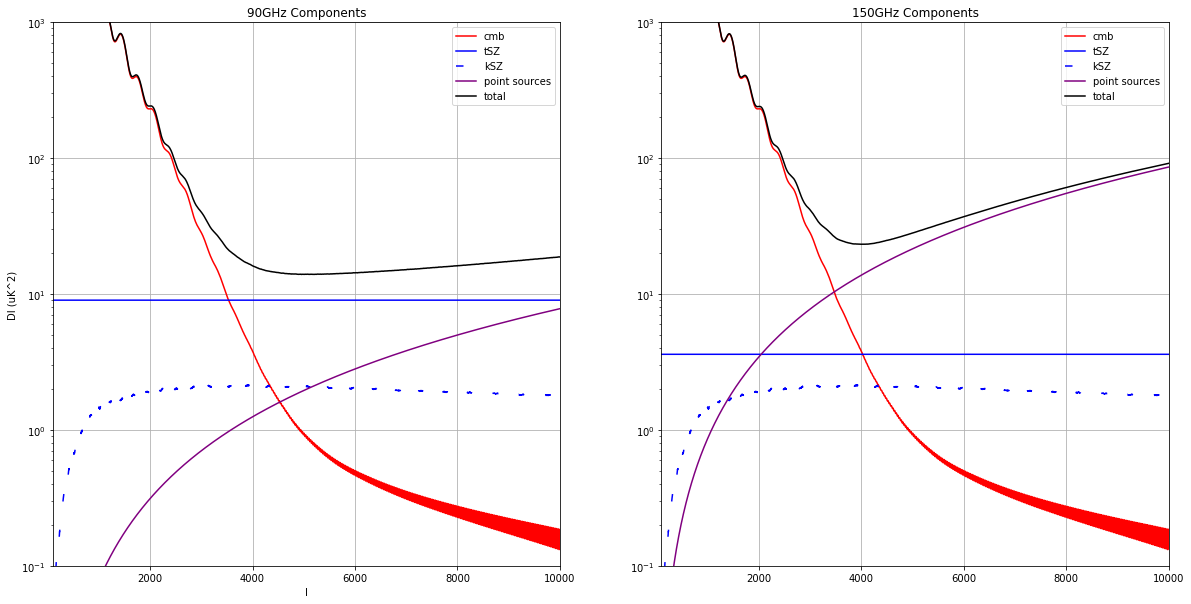

In [10]:
#plot component Dl for sanity checks
if plot_inputs:
    pl.rcParams['figure.figsize'] = [20, 10]
    fig, (ax90,ax150)=pl.subplots(ncols=2,nrows=1)
    total_90=inputs['dlcmb'][:9999]+inputs['dltsz'][0][:9999]+inputs['dlksz'][:9999]+inputs['dlps'][0][:9999]
    total_150=inputs['dlcmb'][:9999]+inputs['dltsz'][1][:9999]+inputs['dlksz'][:9999]+inputs['dlps'][1][:9999]
    ltotal=inputs['lcmb'][:9999]
    ax90.semilogy(inputs['lcmb'],inputs['dlcmb'],color='red',label='cmb')
    ax150.semilogy(inputs['lcmb'],inputs['dlcmb'],color='red',label='cmb')
    ax90.semilogy(inputs['ltsz'],inputs['dltsz'][0],color='blue',label='tSZ')
    ax150.semilogy(inputs['ltsz'],inputs['dltsz'][1],color='blue',label='tSZ')
    ax90.semilogy(inputs['lksz'],inputs['dlksz'],color='blue',linestyle='--', dashes=(5, 20),label='kSZ')
    ax150.semilogy(inputs['lksz'],inputs['dlksz'],color='blue',linestyle='--', dashes=(5, 20),label='kSZ')
    ax90.semilogy(inputs['lps'],inputs['dlps'][0],color='purple',label='point sources')
    ax150.semilogy(inputs['lps'],inputs['dlps'][1],color='purple',label='point sources')
    ax90.semilogy(ltotal,total_90,color='black',label='total')
    ax150.semilogy(ltotal,total_150,color='black',label='total')
    ax90.set_xlim([100,10000])
    ax150.set_xlim([100,10000])
    ax90.set_ylim([.1,1000])
    ax150.set_ylim([.1,1000])
    ax90.set_title('90GHz Components')
    ax150.set_title('150GHz Components')
    ax90.set_xlabel('l')
    ax90.set_ylabel('Dl (uK^2)')
    ax90.legend()
    ax150.legend()
    ax90.grid()
    ax150.grid()
    pl.show()

In [11]:
# #set up noise components:
#read in instrument / atmospheric psds
NoiseInstrument=inputs['instrument_psds']

In [12]:
#astrophysical noise covariance matrix (1d of 2x2 arrays)
astro_ls=[inputs['lcmb'],inputs['ltsz'],inputs['lksz'],inputs['lps']]
astro_cls=[inputs['clcmb'],inputs['cltsz'],inputs['clksz'],inputs['clps']]
ncov1d=clu.create_ncov1d(astro_ls,
                         astro_cls,
                         ell_max,
                         2)

In [13]:
#full astrophysical nxnxbxb covariance matrix
nmatastro=clu.create_ncovbd(ncov1d,beams,psize,nbands,ny,nx,ell_max)

[3360, 3360, 2, 2]


In [14]:
#instrument noise covariance matrix
nmatinst=clu.create_N_d(
    NoiseInstrument)

In [15]:
#full covariance matrix
nmatfull=nmatinst+nmatastro


In [16]:
#read in the cluster profiles
idl_profiles=idlsave.read(pol_directory+profiles_name,verbose=False)
idl_ls=np.arange(80001)

In [17]:
#prepare output for the filter
psis={}
fmaps={}
snmaps={}
predicteds=np.array([])
measureds=np.array([])
maxes=np.array([])
xes=np.array([])
yes=np.array([])
tlocs=np.array([])

0.25


/cvmfs/spt.opensciencegrid.org/py3-v2/RHEL_7_x86_64/lib/python3.6/site-packages/numpy/core/fromnumeric.py:2909: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cvmfs/spt.opensciencegrid.org/py3-v2/RHEL_7_x86_64/lib/python3.6/site-packages/numpy/core/_methods.py:80: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/cvmfs/spt.opensciencegrid.org/py3-v2/RHEL_7_x86_64/lib/python3.6/site-packages/numpy/core/_methods.py:135: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/cvmfs/spt.opensciencegrid.org/py3-v2/RHEL_7_x86_64/lib/python3.6/site-packages/numpy/core/_methods.py:105: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/cvmfs/spt.opensciencegrid.org/py3-v2/RHEL_7_x86_64/lib/python3.6/site-packages/numpy/core/_methods.py:127: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/cvmfs/spt.ope

0.5
0.75
1.0
1.25
1.5
1.75
2.0
2.25
2.5
2.75
3.0


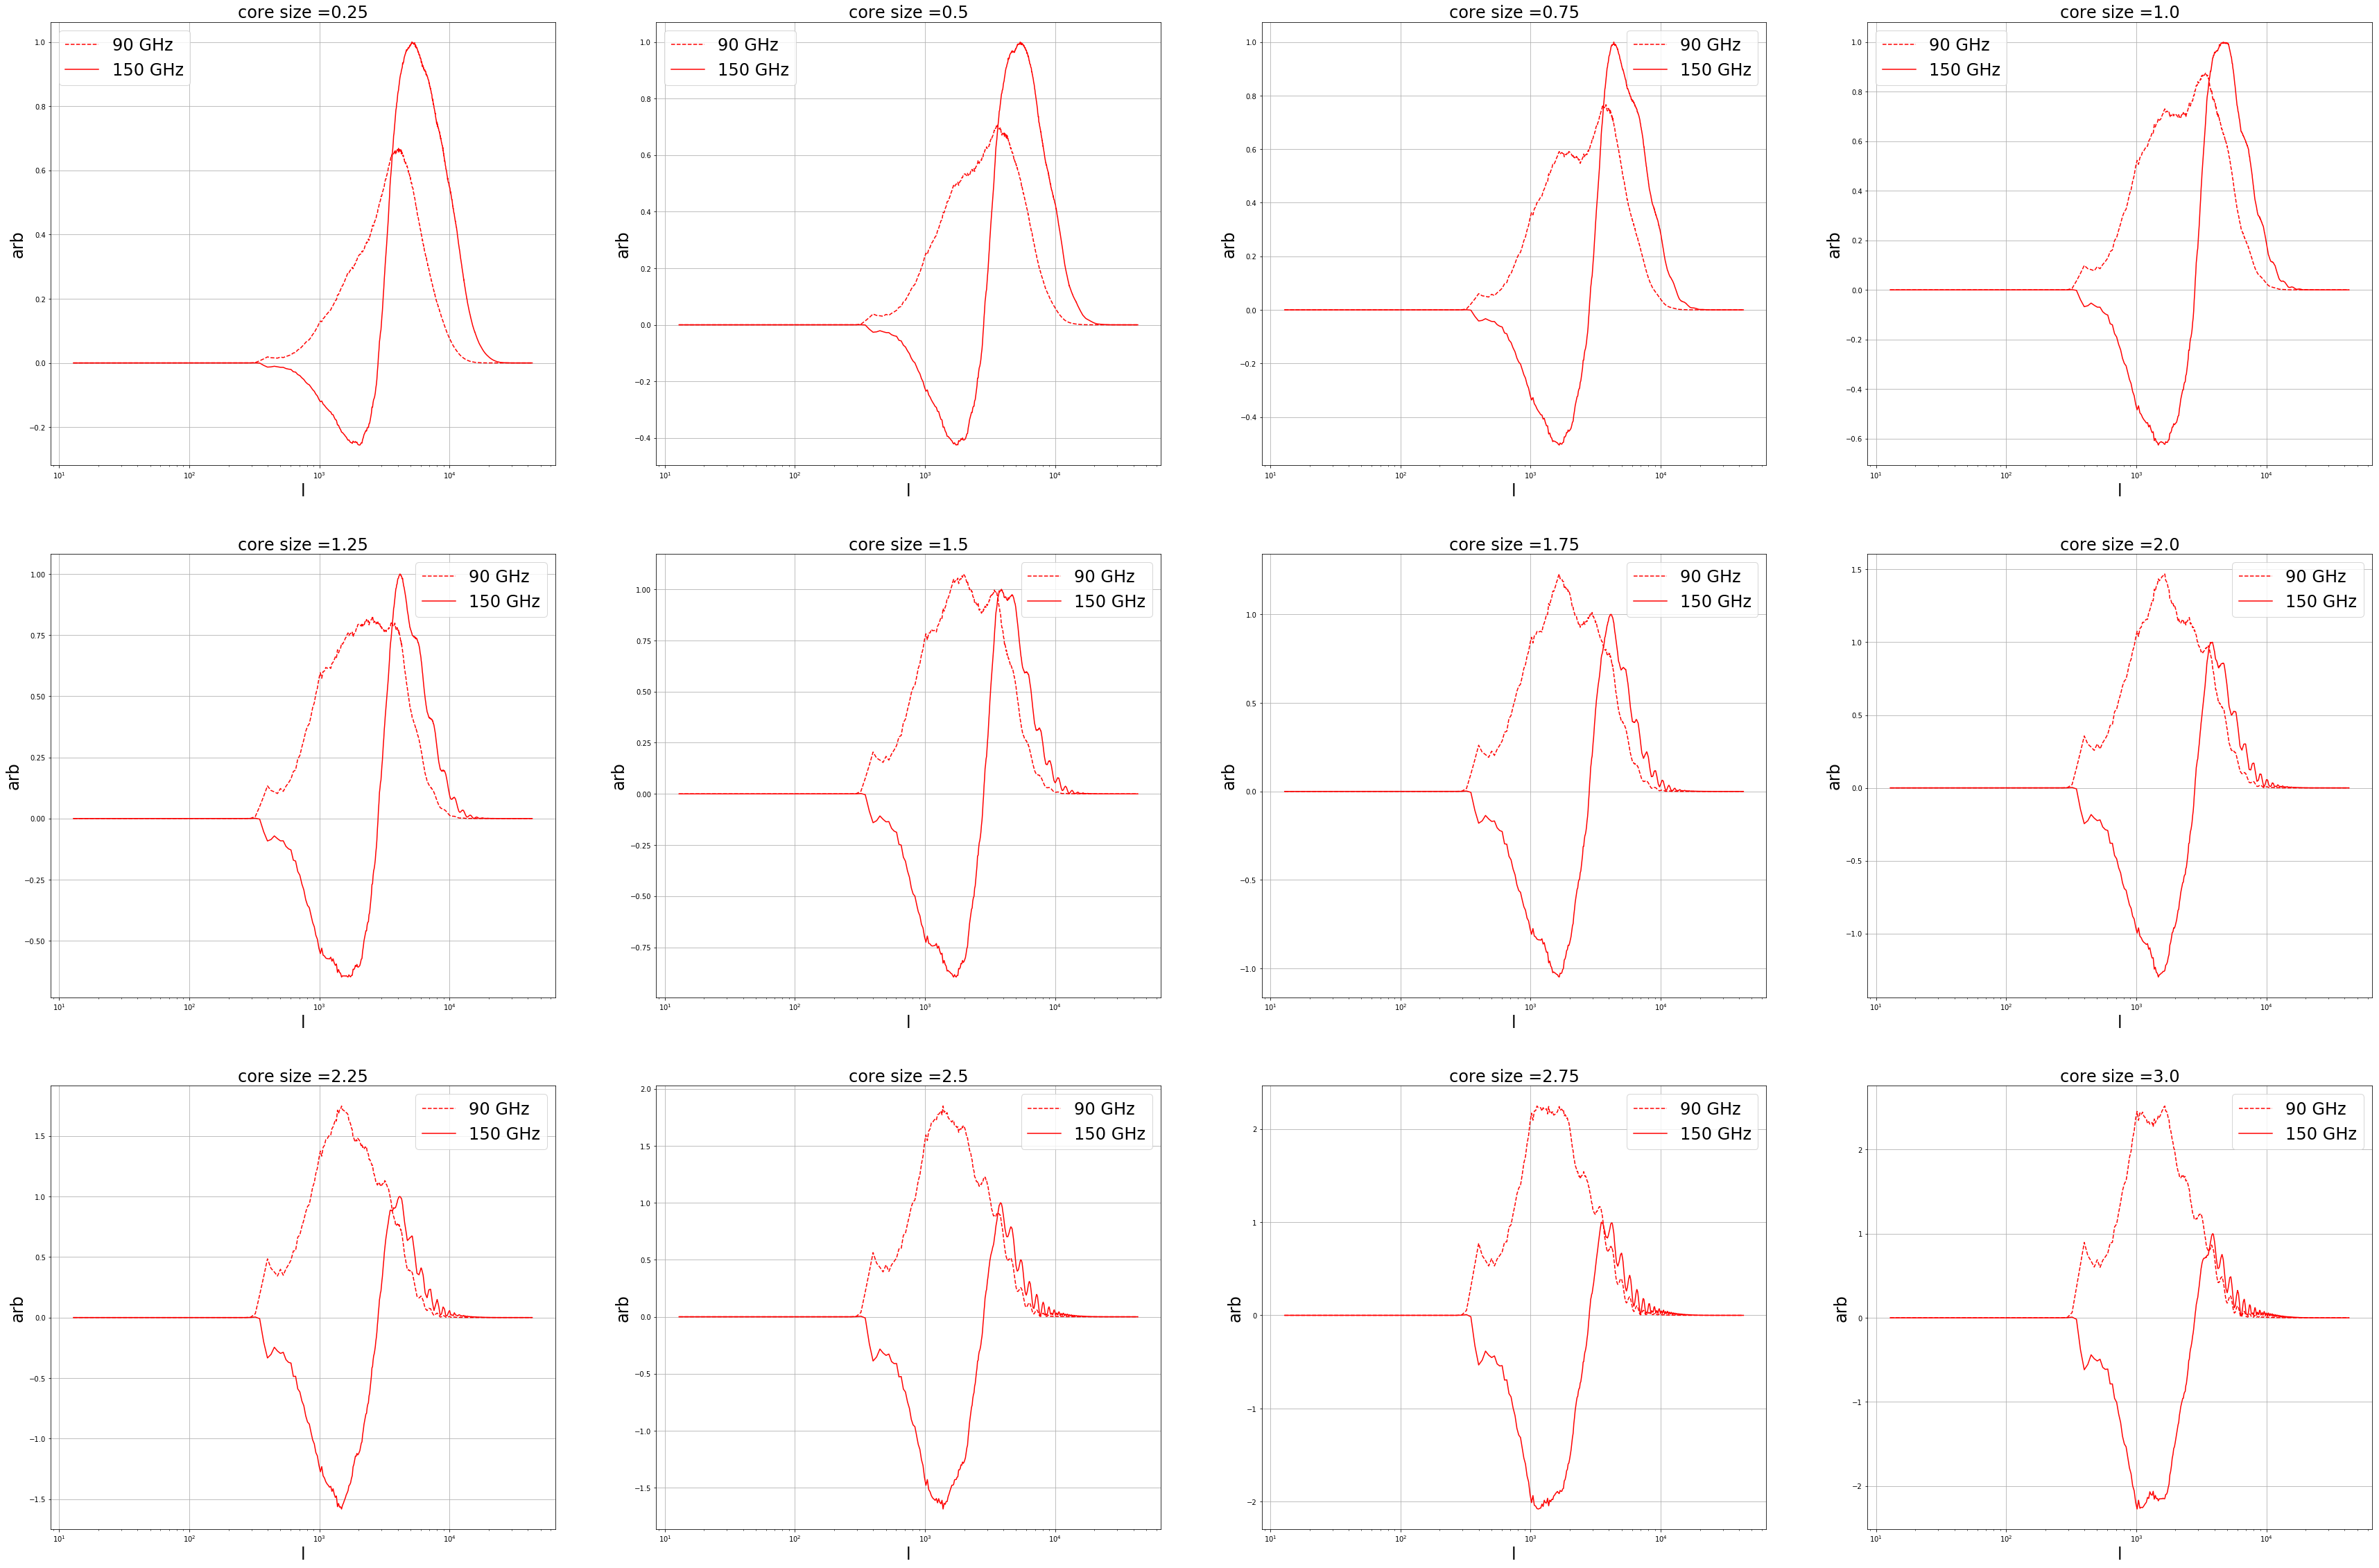

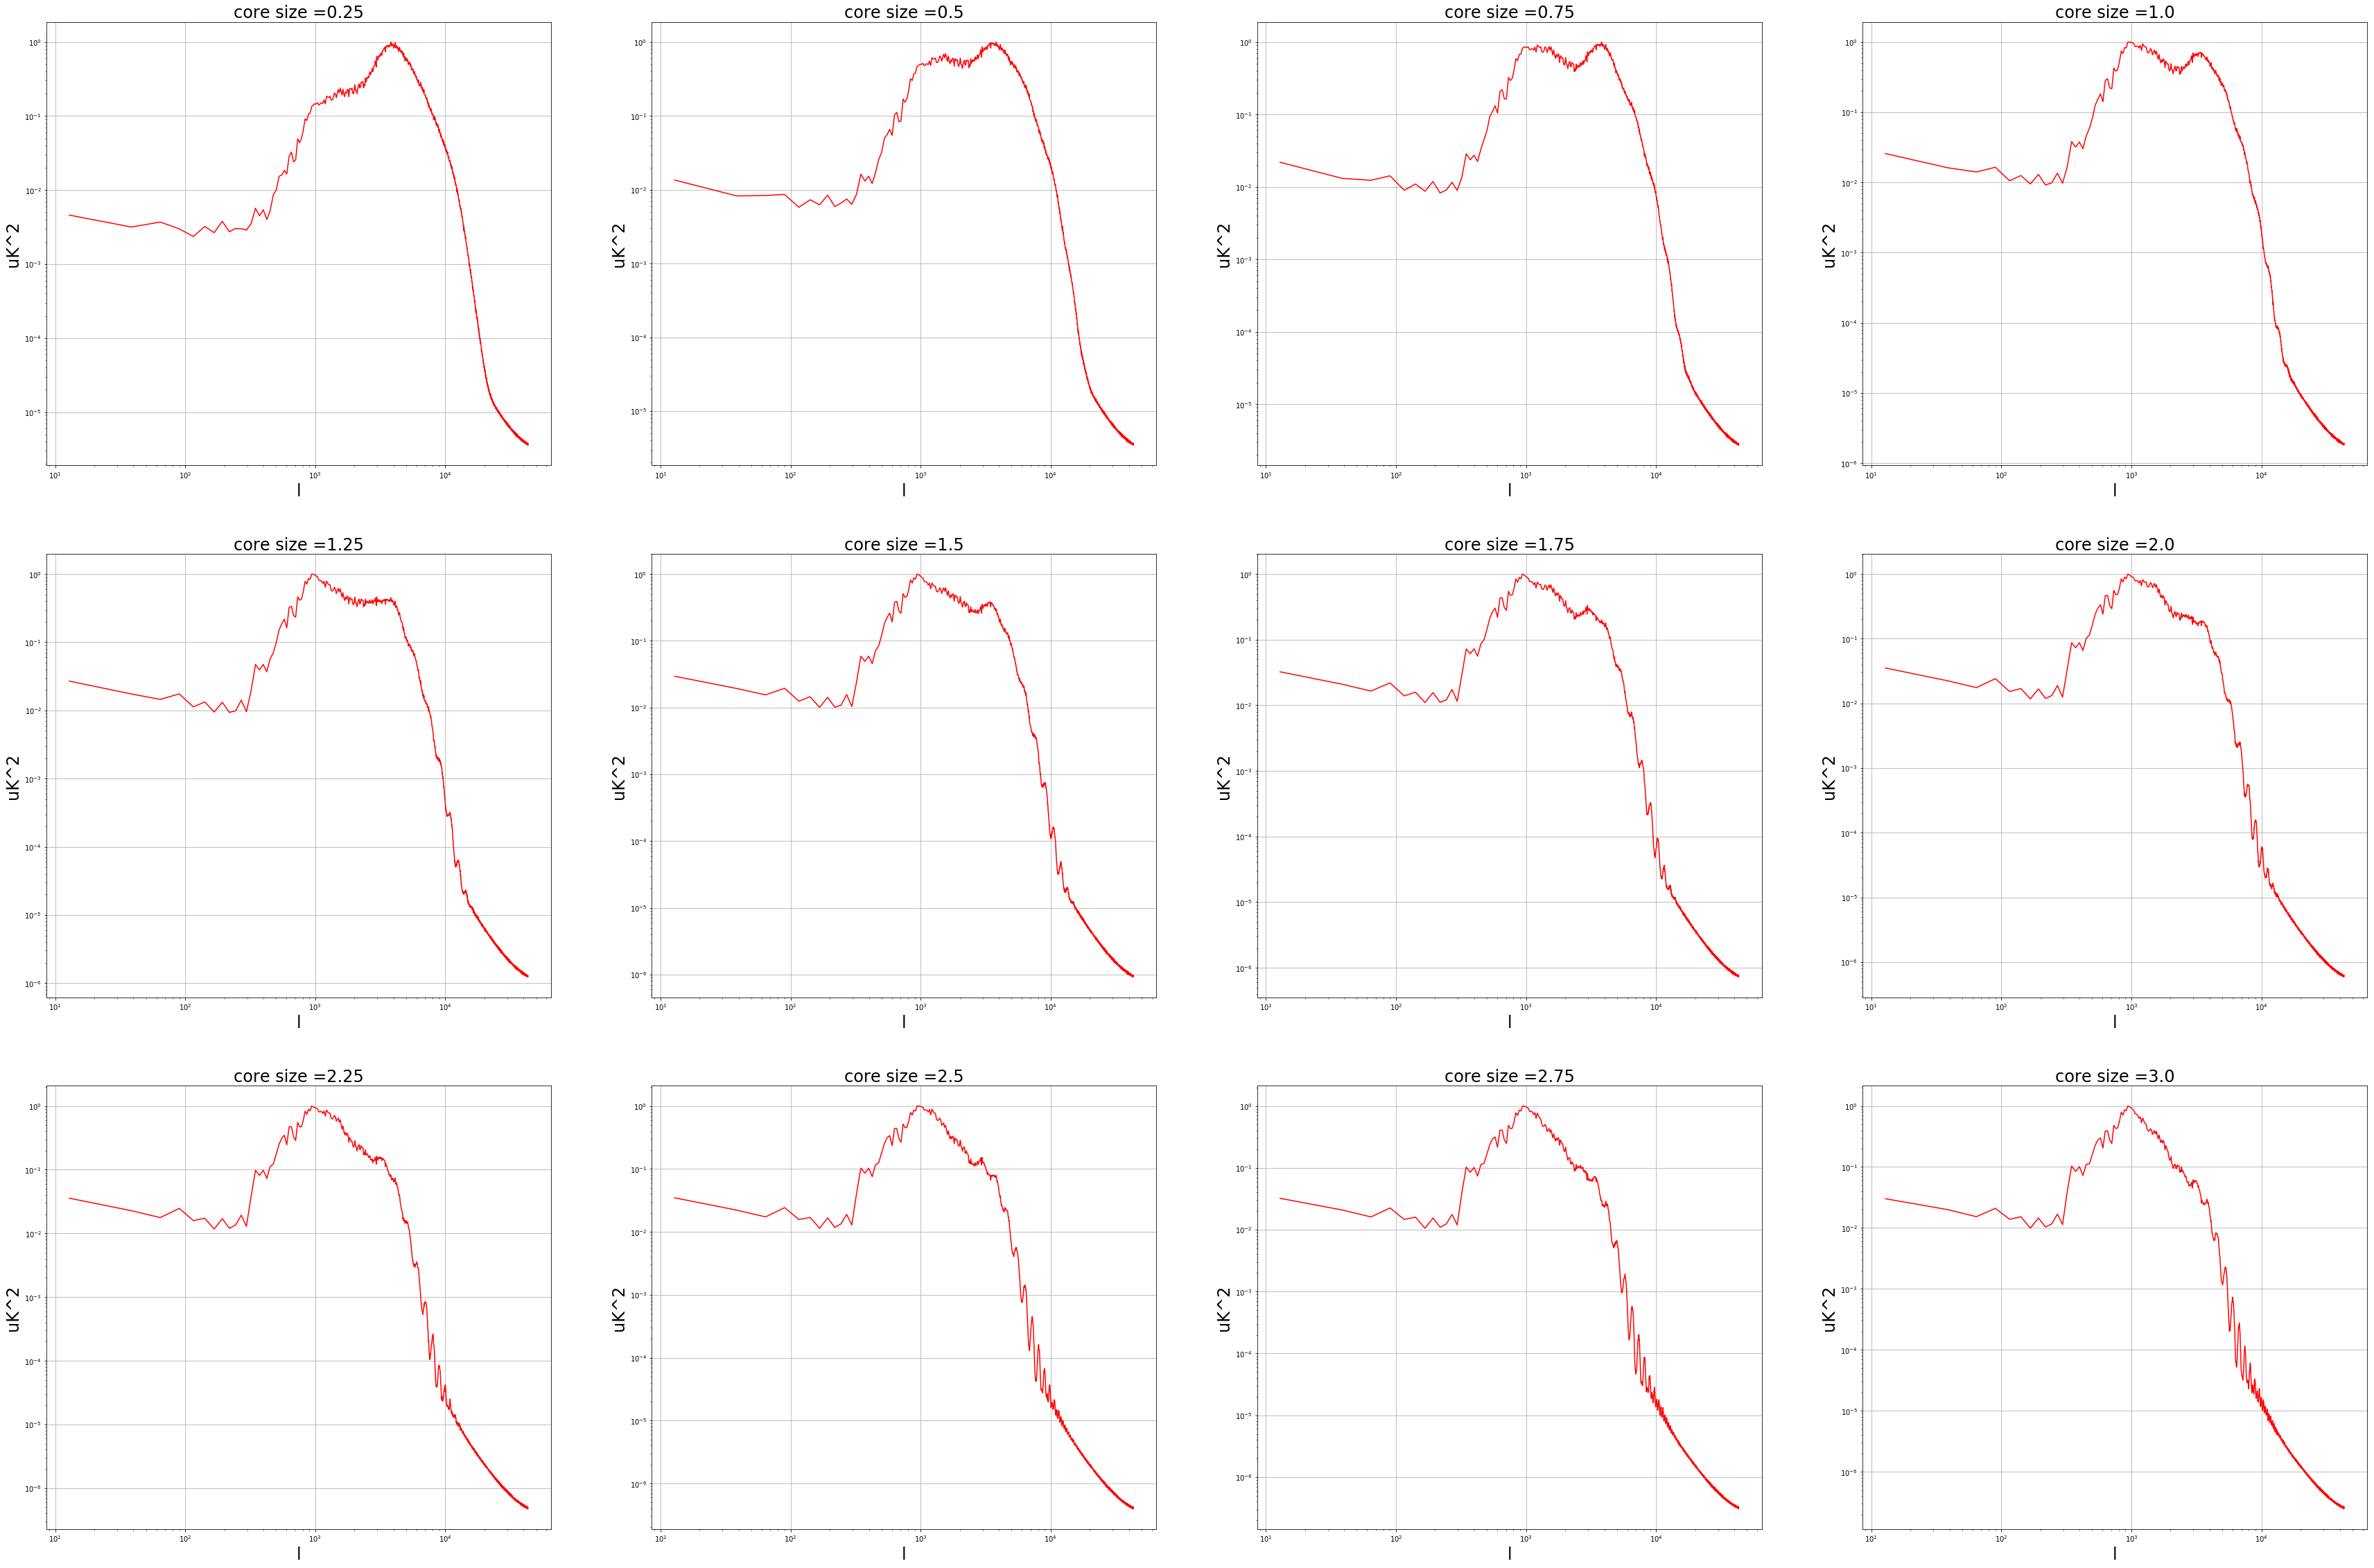

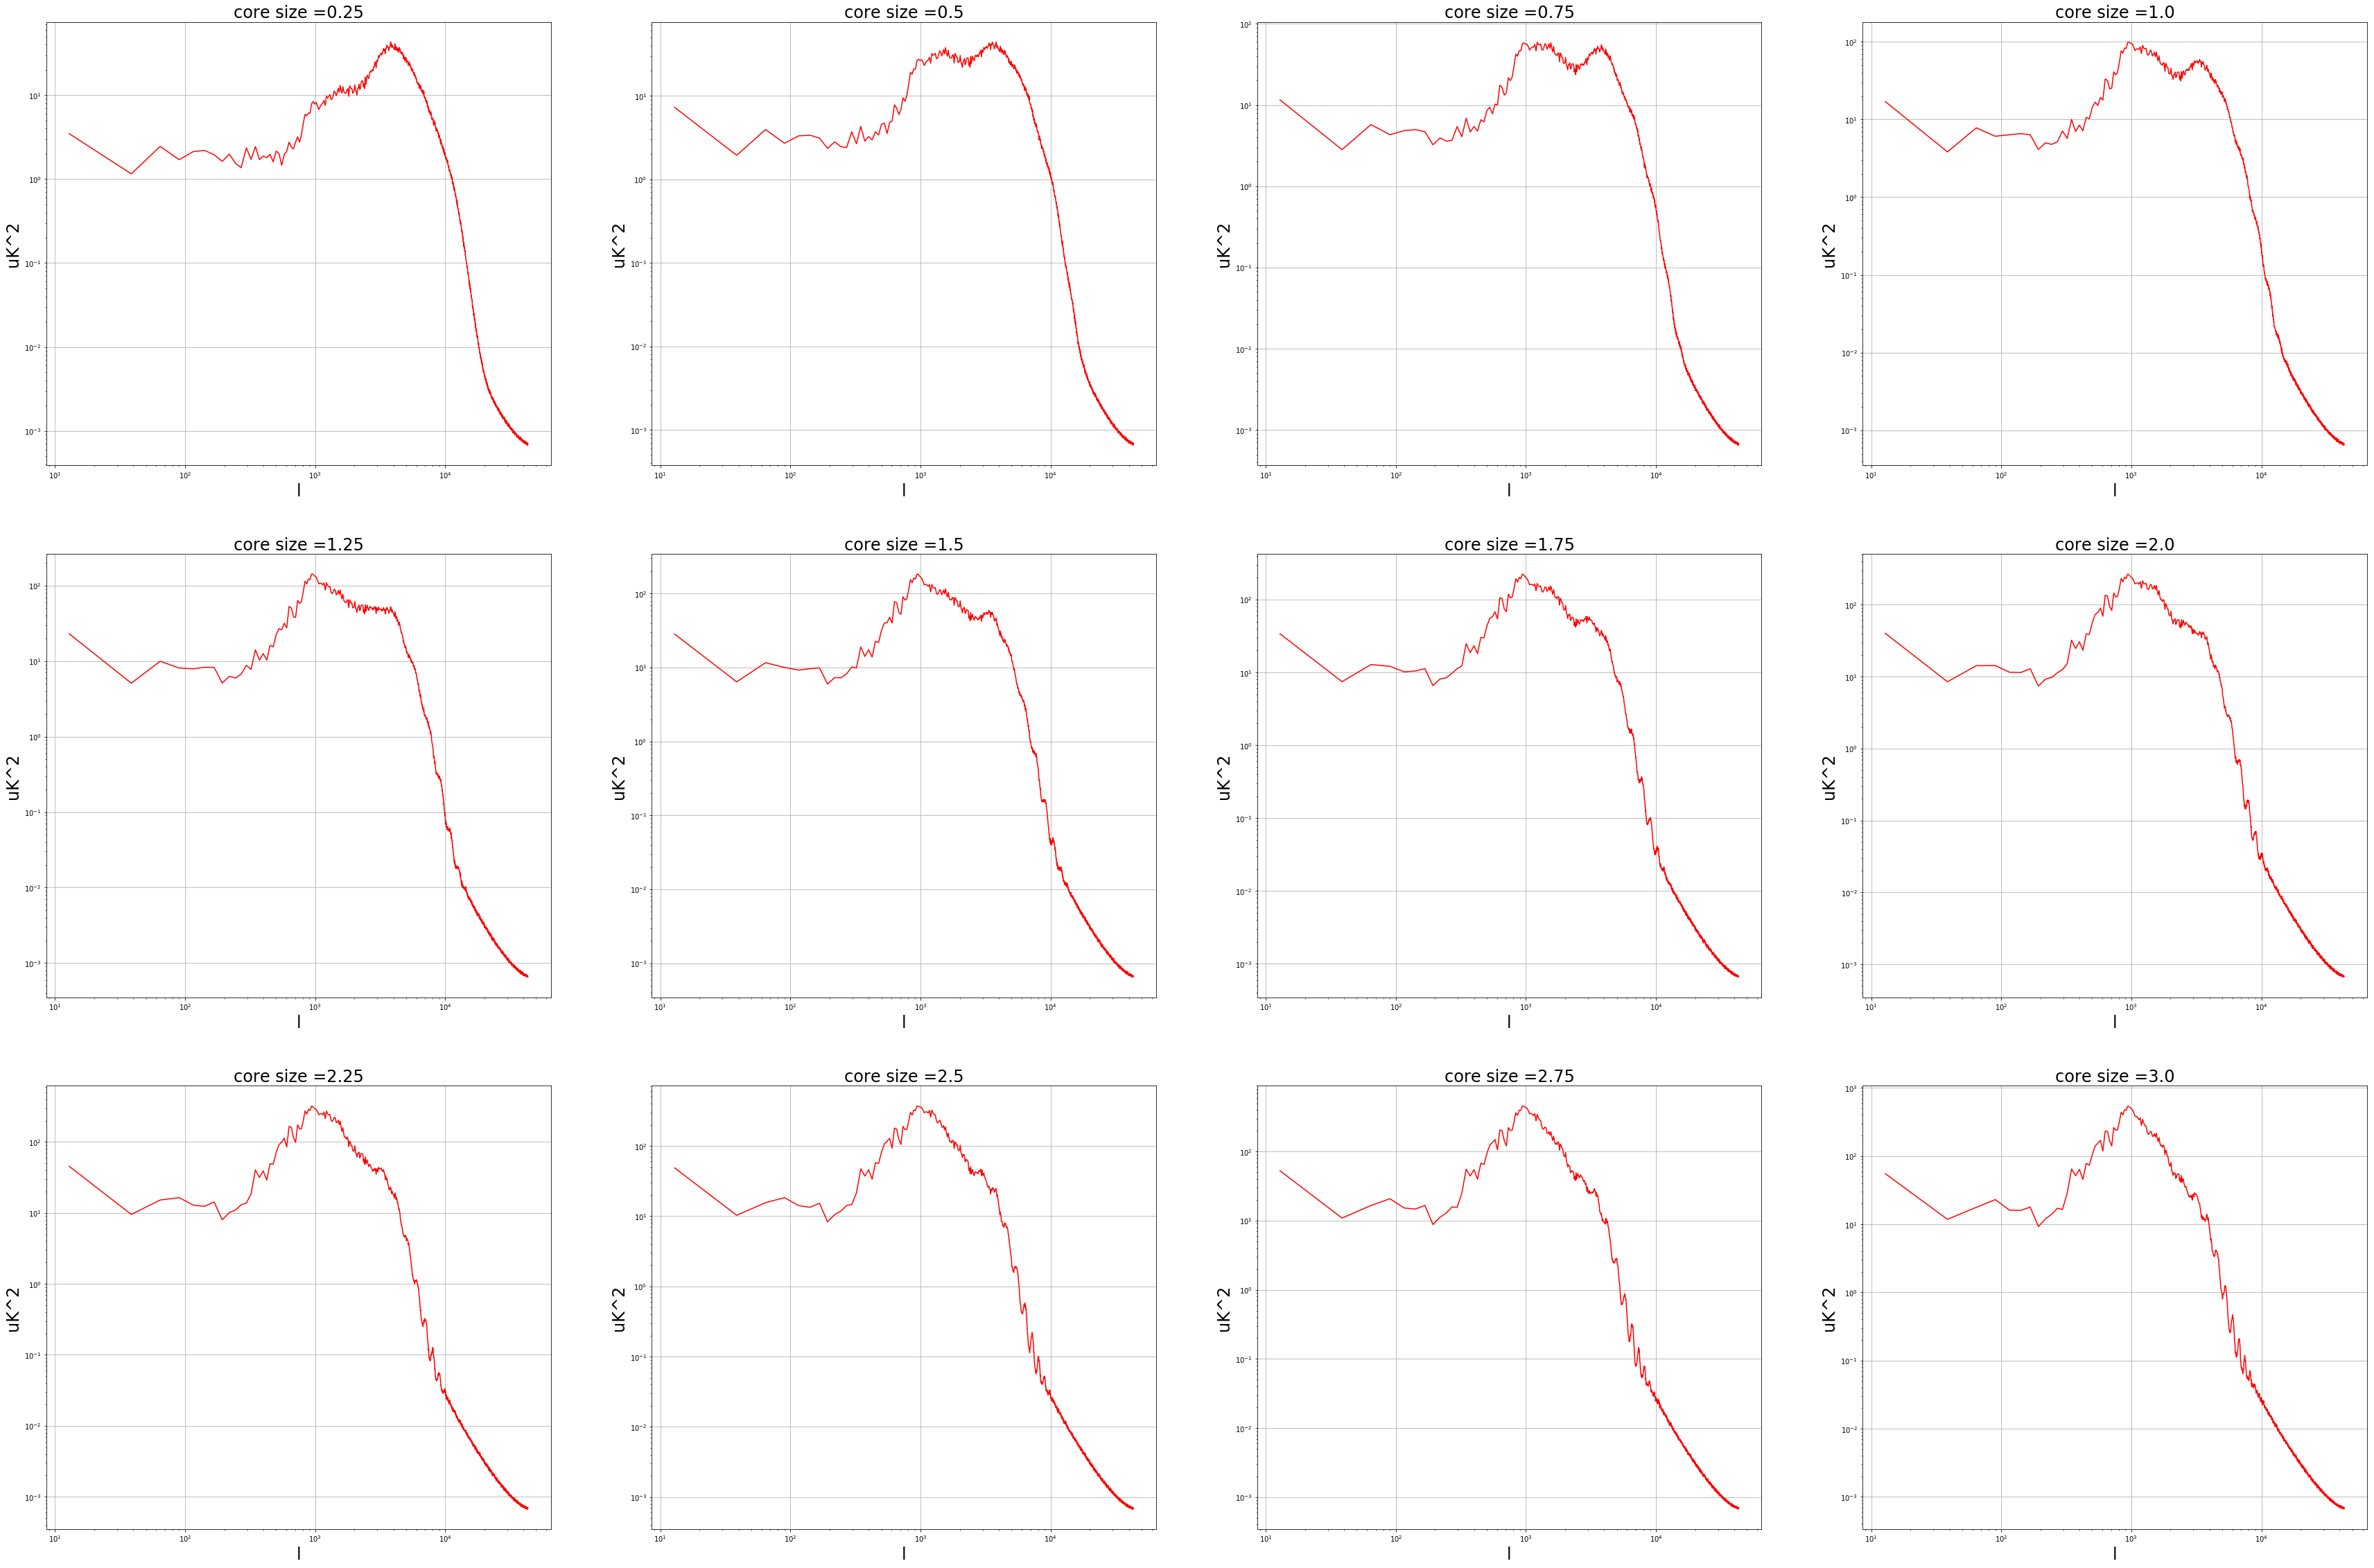

In [18]:
pl.rcParams['figure.figsize'] = [60, 40]
if plot_psi:
    fig, axes=pl.subplots(nrows=3,ncols=4)
    axes=axes.flatten()
    axes[1].set_title('Optimal Filter Comparisons',fontsize=36)
if plot_ps:
    fig2, axes2=pl.subplots(nrows=3,ncols=4)
    fig3, axes3=pl.subplots(nrows=3,ncols=4)
    axes2=axes2.flatten()
    axes3=axes3.flatten()
    axes2[1].set_title('Filtered Map Power Spectra',fontsize=36)
    axes3[1].set_title('Signal To Noise Map Power Spectra',fontsize=36)    
for ti in range(0,len(tcs)):
    print(tc_arcmin[ti])
    profile_ft=clu.gridtomap(clu.ell_grid(psize,ny,nx),idl_profiles['profs'][ti],idl_ls)
    #normalize fourier space profiles to be max valued at 1 in real space
    #this is arbitrary, could normalize differently or not at all
    real_profile=np.fft.fftshift(np.fft.ifft2(profile_ft,norm='ortho'))/psize
    norm_factor=1/np.max(np.real(real_profile))
    profile_ft*=norm_factor
    ft_signal=clu.create_multi_band_s(
        [profile_ft *beams[b] for b in bands])
    psi,sigma=clu.psi_faster(fsz,ft_signal,nmatfull,ny,nx,nbands)
    psi[0][0]=0.0
    if save_psi:
        psis[t]=psi
    predicteds=np.append(predicteds,sigma)
    if plot_psi:
        pypsi=np.reshape(np.split(psi,2,axis=2),(2, 3360, 3360)) 
        py90=basicmaputils.av_ps(-1*pypsi[0],
                                 .25*core.G3Units.arcmin,
                                 ell_bins,s=(ny,nx),real=False)
        py150=basicmaputils.av_ps(-1*pypsi[1],
                                  .25*core.G3Units.arcmin,
                                  ell_bins,s=(ny,nx),real=False)
        axes[ti].semilogx(ell_plot,
                        py90/np.max(py150),
                        linestyle='--',
                        color='red',
                        label='90 GHz')
        axes[ti].semilogx(ell_plot,
                         py150/np.max(py150),
                         linestyle='-',
                         color='red',
                         label='150 GHz')
        axes[ti].set_title('core size ='+str(tc_arcmin[ti]),fontsize=24)
        axes[ti].grid()
        axes[ti].set_xlabel('l',fontsize=24)
        axes[ti].set_ylabel('arb',fontsize=24)
        axes[ti].legend(fontsize=24)
    #create filtered maps
    fmap=clu.multi_band_filter(skymaps,psi,psize,nbands)
    measureds=np.append(measureds,np.std(fmap))
    if save_maps:
        fmaps[ti]=fmap
    snmap=clu.make_snmaps([fmap],
                          apod2,
                          mask2,
                          psize,
                          cutoffs=None)[0]
    if save_maps:
        snmaps[ti]=snmap
    if plot_ps:
        #apodize and mask maps and take power spectra
        pyps=np.abs(np.fft.fft2(fmap*apod2,norm='ortho'))**2
        pyps_sn=np.abs(np.fft.fft2(snmap*apod2*mask2,norm='ortho'))**2
        #average power spectra
        pyav =basicmaputils.av_ps(pyps,.25*core.G3Units.arcmin,ell_bins,s=(ny,nx),real=False)
        pyav_sn =basicmaputils.av_ps(pyps_sn,.25*core.G3Units.arcmin,ell_bins,s=(ny,nx),real=False)
        axes2[ti].loglog(ell_plot,pyav/np.max(pyav),color='red')
        axes2[ti].set_title('core size ='+str(tc_arcmin[ti]),fontsize=24)
        axes2[ti].grid()
        axes2[ti].legend(fontsize=24)
        axes2[ti].set_xlabel('l',fontsize=24)
        axes2[ti].set_ylabel('uK^2',fontsize=24)
        axes3[ti].loglog(ell_plot,pyav_sn,color='red')
        axes3[ti].set_title('core size ='+str(tc_arcmin[ti]),fontsize=24)
        axes3[ti].grid()
        axes3[ti].set_xlabel('l',fontsize=24)
        axes3[ti].set_ylabel('uK^2',fontsize=24)    
    groups=sources.source_utils.find_groups(snmap,
                                            signoise=1,
                                            nsigma=sn_cutoff)
    maxes=np.append(maxes,groups['maxvals'])
    xes=np.append(xes,groups['xcen'])
    yes=np.append(yes,groups['ycen'])
    tlocs=np.append(tlocs,tcs[ti]*np.ones(groups['n_detected']))
pl.show()

In [19]:
zipped=np.array(sorted(zip(maxes,xes,yes,tlocs),reverse=True))
cat={}
cat['sigs']=np.array([])
cat['xvals']=np.array([])
cat['yvals']=np.array([])
cat['tcs']=np.array([])
candidates=zipped.copy()
coords=candidates[:,[1,2]]
while len(candidates>0):
    cat['sigs']=np.append(cat['sigs'],candidates[0][0])
    cat['xvals']=np.append(cat['xvals'],candidates[0][1])
    cat['yvals']=np.append(cat['yvals'],candidates[0][2])
    cat['tcs']=np.append(cat['tcs'],candidates[0][3])    
    coords, candidates=clu.remove_duplicates(0,coords,candidates,16)   

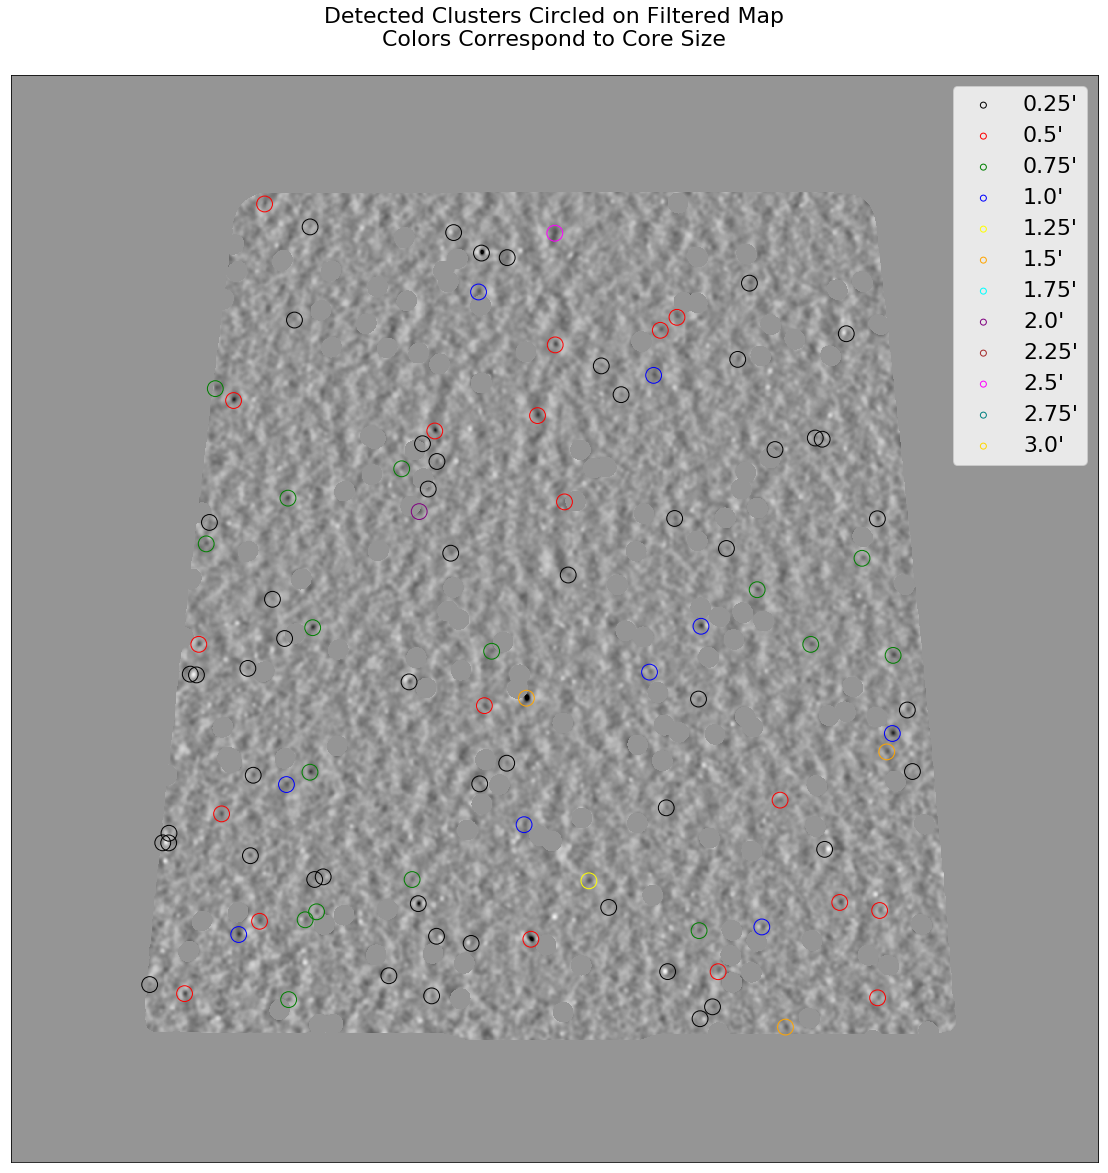

In [20]:
pl.rcParams['figure.figsize']=[20,20]
fig, (ax1) = pl.subplots()
ax1.imshow(snmap,vmin=-10,vmax=10,cmap='Greys')
ax1.scatter(cat['xvals'],
            cat['yvals'],
            facecolors='none',
            edgecolors=[tc_colors[t] for t in cat['tcs']],
            s=250)
for tc in tcs:
    ax1.scatter([],[],facecolors='none',edgecolors=tc_colors[tc],label=str(tc*psize)+'\'')
ax1.legend(loc=0,fontsize=22)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Detected Clusters Circled on Filtered Map\n'+
              'Colors Correspond to Core Size\n',
             fontsize=22)

In [21]:
cat.keys()

dict_keys(['sigs', 'xvals', 'yvals', 'tcs'])